# Experimental data: Path Lifting & Analysis

This notebook demonstrates the full pipeline on real Gardner et al. (https://www.nature.com/articles/s41586-021-04268-7) grid cell data:
1. Load spike data and position from the Gardner dataset
2. Extract toroidal coordinates and apply path lifting
3. Align recovered trajectory to ground-truth position
4. Compute global reconstruction error
5. Compute local reconstruction error

In [24]:
import os, sys
from pathlib import Path
import time
import math

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.ndimage import gaussian_filter1d
from scipy.stats import ttest_ind


# Ensure repo-root imports work no matter where the notebook kernel starts.
repo_root = Path.cwd()
if not (repo_root / "constants.py").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

sys.path.append('.')



from constants import GARDNER_DATA_PATH
from helper_scripts.utils import get_spikes
from helper_scripts.Gardner_lifting_test import interpolate_2d_along_axis_0
from toroidal_coordinates.Gardner_toroidal import Gardner_coord
from toroidal_coordinates.compute_coord import interp_arr, plot_toroidal_coordinates
from pipelines import (
    recover_traj_pipeline,
    compare_lifted_pipeline,
    segmental_compare_pipeline,
    plot_trajectory_comparison,
)

## 1. Load Gardner Data

Using rat R, module 1, open field session, day 2 — the standard example session.

In [4]:
RAT_NAME  = 'R'
MOD_NAME  = '1'
SESS_NAME = 'OF'
DAY_NAME  = 'day2'

sspikes, xx, yy, _, _ = get_spikes(
    RAT_NAME, MOD_NAME, DAY_NAME, SESS_NAME,
    bType='pure', bSmooth=True, bSpeed=True,
    folder=GARDNER_DATA_PATH,
)
original_coord = np.column_stack((xx, yy))

print(f"Spike matrix shape: {sspikes.shape}  (n_timesteps x n_cells)")
print(f"Position arrays: xx={xx.shape}, yy={yy.shape}")

Spike matrix shape: (126728, 111)  (n_timesteps x n_cells)
Position arrays: xx=(126728,), yy=(126728,)


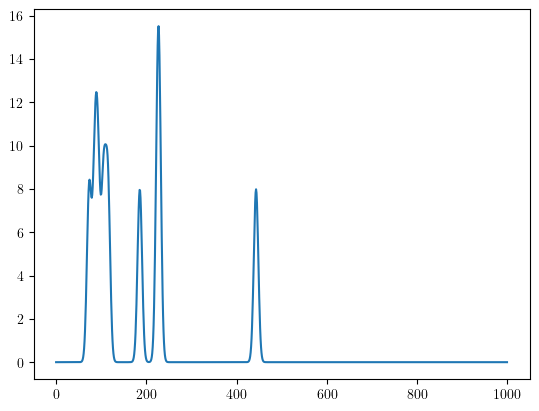

In [5]:
plt.plot(sspikes[:1000, 0])
plt.show()

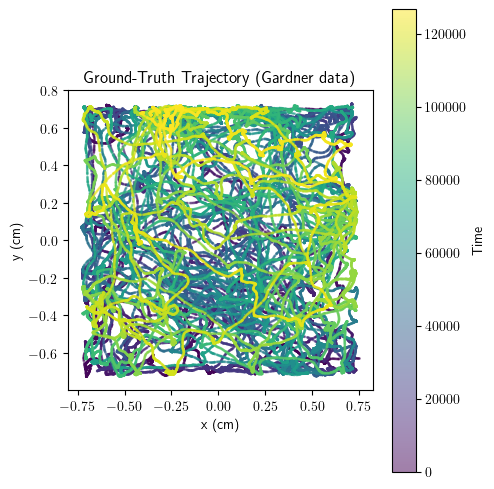

In [6]:
# Visualize the animal's ground-truth trajectory
fig, ax = plt.subplots(figsize=(5, 5))
sc = ax.scatter(xx, yy, c=np.arange(len(xx)), cmap='viridis', s=1, alpha=0.5)
plt.colorbar(sc, ax=ax, label='Time')
ax.set_title('Ground-Truth Trajectory (Gardner data)')
ax.set_xlabel('x (cm)')
ax.set_ylabel('y (cm)')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## 2. Extract Toroidal Coordinates & Apply Path Lifting

In [7]:
# recover_traj_pipeline expects activity in shape (n_cells, n_timesteps)

start_time = time.time()
tor_coord, lifted_coord = recover_traj_pipeline(sspikes.T)
end_time = time.time()
print(f"Total run time: {end_time - start_time} seconds")

lifted_coord_smooth = lifted_coord.copy()
lifted_coord_smooth[:, 0] = gaussian_filter1d(lifted_coord[:, 0], 10)
lifted_coord_smooth[:, 1] = gaussian_filter1d(lifted_coord[:, 1], 10)

print(f"Toroidal coord shape: {tor_coord.shape}")
print(f"Lifted coord shape:   {lifted_coord.shape}")

dreimac failed, falling back to gardner


/home/hyoon/GridPathLifting/toroidal_coordinates/Gardner_toroidal.py:155: RuntimeWarning: divide by zero encountered in log
  d = -np.log(d)


DISTANCE_THRESHOLD: 0.5186296604861926
Total run time: 33.2477068901062 seconds
Toroidal coord shape: (126728, 2)
Lifted coord shape:   (126728, 2)


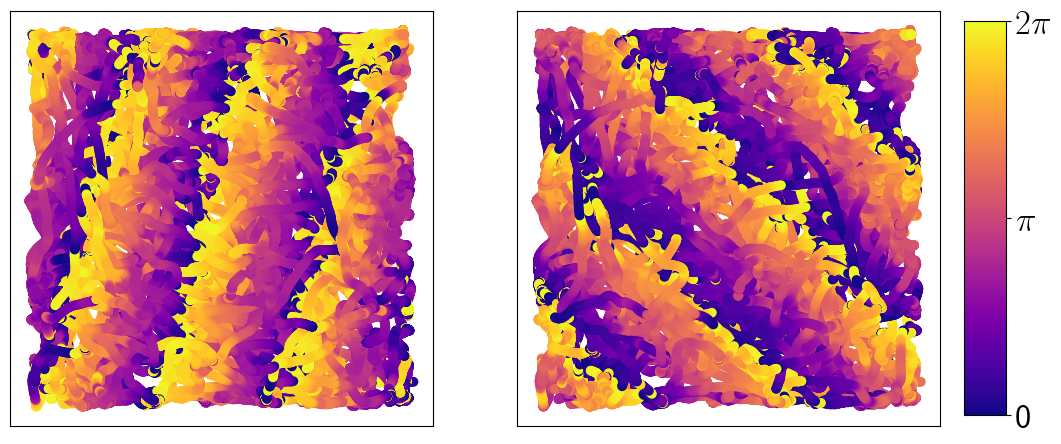

In [8]:
# plot toroidal coordinates
plot_toroidal_coordinates(xx, yy, tor_coord, np.arange(0, 126728))
plt.show()

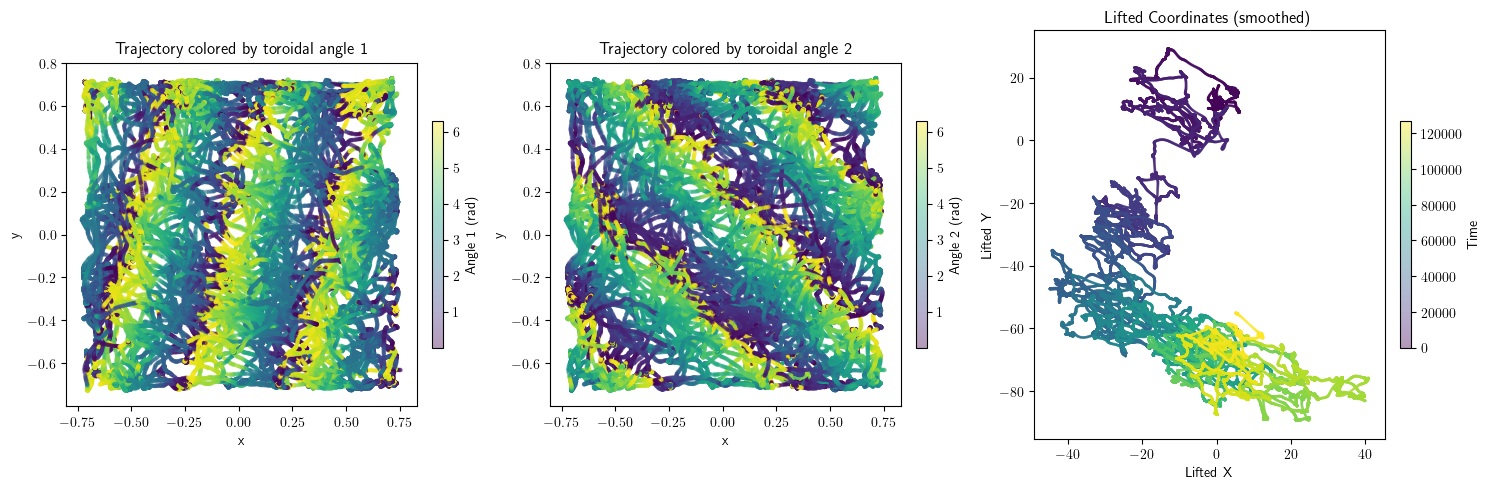

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Trajectory colored by toroidal angle 1
sc1 = axes[0].scatter(xx, yy, c=tor_coord[:, 0], cmap='viridis', s=5, alpha=0.4)
axes[0].set_title('Trajectory colored by toroidal angle 1')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')
axes[0].set_aspect('equal')
plt.colorbar(sc1, ax=axes[0], label='Angle 1 (rad)', fraction=0.03, pad=0.04)

# Trajectory colored by toroidal angle 2
sc2 = axes[1].scatter(xx, yy, c=tor_coord[:, 1], cmap='viridis', s=5, alpha=0.4)
axes[1].set_title('Trajectory colored by toroidal angle 2')
axes[1].set_xlabel('x'); axes[1].set_ylabel('y')
axes[1].set_aspect('equal')
plt.colorbar(sc2, ax=axes[1], label='Angle 2 (rad)', fraction=0.03, pad=0.04)

# Lifted coordinates
sc3 = axes[2].scatter(lifted_coord_smooth[:, 0], lifted_coord_smooth[:, 1],
                      c=np.arange(len(lifted_coord_smooth)), cmap='viridis', s=1, alpha=0.4)
axes[2].set_title('Lifted Coordinates (smoothed)')
axes[2].set_xlabel('Lifted X'); axes[2].set_ylabel('Lifted Y')
plt.colorbar(sc3, ax=axes[2], label='Time', fraction=0.03, pad=0.04)

plt.tight_layout()
plt.show()

## 3. Global reconstruction error

In [10]:
lifted_coord_transformed, overall_score = compare_lifted_pipeline(lifted_coord_smooth, original_coord, world_size = 1.5)
print(f"Overall reconstruction error: {overall_score:.6f}")

Mismatch score: 0.3708435397337515
Overall reconstruction error: 0.370844


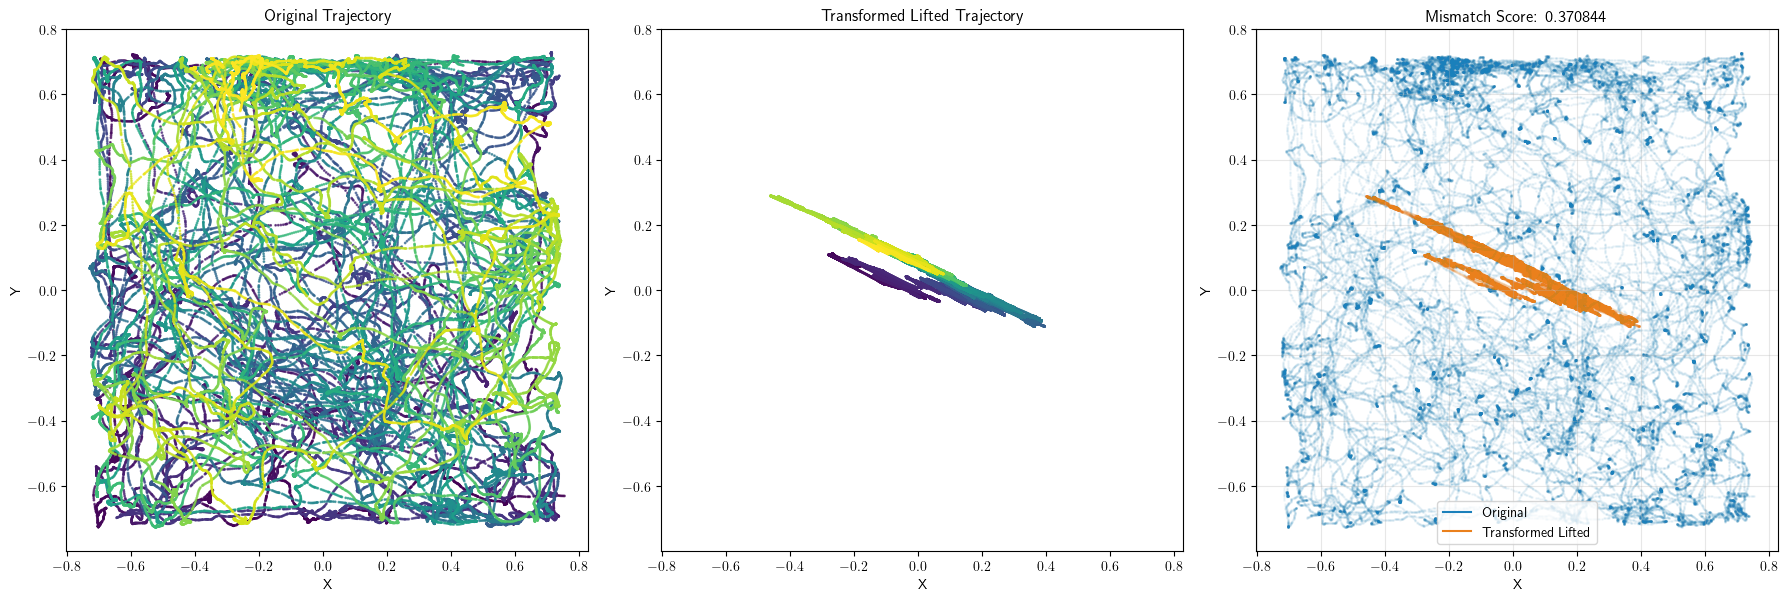

In [11]:
plot_trajectory_comparison(original_coord, lifted_coord_transformed, overall_score)

## 4. Local reconstruction error

### 4(a) Plot local paths

In [12]:
from affine_transform.get_transform_mat import get_transform_mat, apply_transform_mat
from affine_transform.score_mismatch import score_mismatch
np.random.seed(0)
LEN_SEG = 2000
print(f"Segment length: {LEN_SEG} timepoints")


colors = plt.cm.viridis(np.linspace(0, 1, LEN_SEG))

Segment length: 2000 timepoints


#### Plot segment 36 in detail 

In [13]:
i = 36
original_seg = original_coord[i*LEN_SEG:(i+1)*LEN_SEG]
lifted_seg = lifted_coord[i*LEN_SEG:(i+1)*LEN_SEG]
coords_seg = tor_coord[i*LEN_SEG:(i+1)*LEN_SEG]
transform_mat = get_transform_mat(lifted_seg, original_seg)
recovered_lifted = apply_transform_mat(lifted_seg, transform_mat)


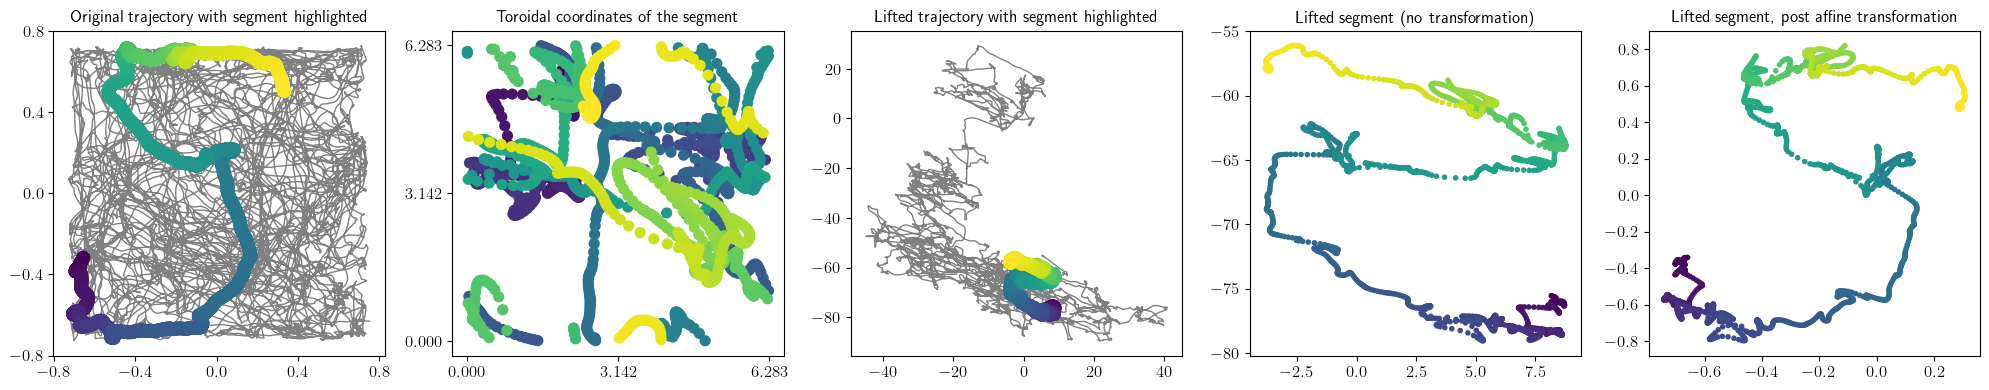

In [14]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

# 1. Original trajectory with segment highlighted
axes[0].plot(original_coord[:, 0], original_coord[:, 1], linewidth=1, color="grey", zorder=0)
axes[0].scatter(original_seg[:, 0], original_seg[:, 1], color=colors, linewidth=4, zorder=1)
axes[0].set_xticks([-0.8, -0.4, 0.0, 0.4, 0.8])
axes[0].set_yticks([-0.8, -0.4, 0.0, 0.4, 0.8])
axes[0].tick_params(labelsize=12)
axes[0].set_title("Original trajectory with segment highlighted")

# 2. Path on the torus
axes[1].scatter(coords_seg[:, 0], coords_seg[:, 1], marker='.', s=200, color=colors)
axes[1].set_xticks([0, math.pi, 2 * math.pi])
axes[1].set_yticks([0, math.pi, 2 * math.pi])
axes[1].tick_params(labelsize=12)
axes[1].set_title("Toroidal coordinates of the segment")


# 3. Lifted trajectory with segment highlighted
axes[2].plot(lifted_coord_smooth[:, 0], lifted_coord_smooth[:, 1], linewidth=1, color="grey", zorder=0)
axes[2].scatter(lifted_seg[:, 0], lifted_seg[:, 1], color=colors, linewidth=4, zorder=1)
axes[2].tick_params(labelsize=12)
axes[2].set_title("Lifted trajectory with segment highlighted")

# 4. Lifted segment (without transformation)
axes[3].scatter(lifted_seg[:, 0], lifted_seg[:, 1], marker='.', color=colors)
axes[3].tick_params(labelsize=12)
axes[3].set_title("Lifted segment (no transformation)")

# 5. Lifted segment (with transformation)
axes[4].scatter(recovered_lifted[:, 0], recovered_lifted[:, 1], marker='.', color=colors)
axes[4].tick_params(labelsize=12)
axes[4].set_title("Lifted segment, post affine transformation")

plt.tight_layout()
plt.show()

### 4(b) Compute local recosntruction errors

Segment length: 2000 timepoints
Segmental mismatch scores: mean=0.094696, std=0.050898


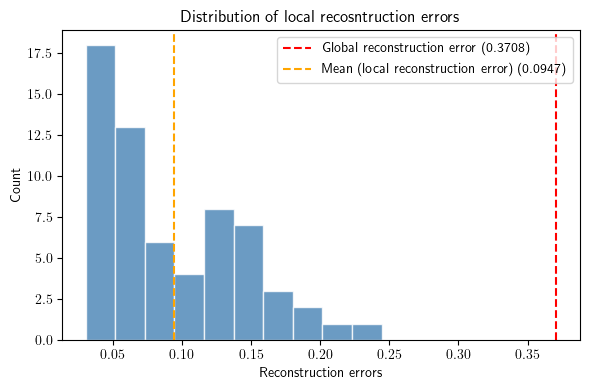


Summary:
  Overall mismatch:          0.370844
  Segmental mean ± std:      0.094696 ± 0.050898
  Segmental min / max:       0.030596 / 0.244414


In [15]:
# Segment length: ~10% of total trajectory
LEN_SEG = 2000
print(f"Segment length: {LEN_SEG} timepoints")

seg_scores = segmental_compare_pipeline(lifted_coord_smooth, original_coord, LEN_SEG)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(seg_scores, bins=10, color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(overall_score, color='red', linestyle='--', label=f'Global reconstruction error ({overall_score:.4f})')
ax.axvline(np.mean(seg_scores), color='orange', linestyle='--', label=f'Mean (local reconstruction error) ({np.mean(seg_scores):.4f})')
ax.set_xlabel('Reconstruction errors')
ax.set_ylabel('Count')
ax.set_title('Distribution of local recosntruction errors')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nSummary:")
print(f"  Overall mismatch:          {overall_score:.6f}")
print(f"  Segmental mean ± std:      {np.mean(seg_scores):.6f} ± {np.std(seg_scores):.6f}")
print(f"  Segmental min / max:       {np.min(seg_scores):.6f} / {np.max(seg_scores):.6f}")

Compute baseline error (error between pairs of local paths)

In [16]:
num_seg = lifted_coord.shape[0]//LEN_SEG+1

mismatch_matrix = np.zeros((num_seg-1, num_seg-1))
for i in range(num_seg-1):
    for j in range(i+1, num_seg-1):
        original_seg1 = original_coord[i*LEN_SEG:(i+1)*LEN_SEG]
        original_seg2 = original_coord[j*LEN_SEG:(j+1)*LEN_SEG]
        affine_mat = get_transform_mat(original_seg2, original_seg1)
        transformed_seg2 = apply_transform_mat(original_seg2, affine_mat)

        # for mismatch scores between local paths, we don't know the true world size. We therefore infer them from the two segments.
        world_size1 = np.max([original_seg1[:, 0].max() - original_seg1[:, 0].min(),
                     original_seg1[:, 1].max() - original_seg1[:, 1].min()])
        world_size2 = np.max([original_seg2[:, 0].max() - original_seg2[:, 0].min(),
                        original_seg2[:, 1].max() - original_seg2[:, 1].min()])
        world_size = np.mean([world_size1, world_size2])

        mismatch_matrix[i, j] = score_mismatch(original_seg1, transformed_seg2, world_size = world_size)
        # here, we use the world_size to be the mean (size of segment 1, size of segment 2))

null_mismatch = mismatch_matrix.flatten()
null_mismatch = null_mismatch[null_mismatch > 0]
print(f"Mean and std of null distribution of mismatch scores (all pairwise segment comparisons):")
null_mismatch.mean(), null_mismatch.std()

Mean and std of null distribution of mismatch scores (all pairwise segment comparisons):


(0.23690673423123956, 0.07661334935710266)

In [17]:
ttest_ind(seg_scores, null_mismatch)

TtestResult(statistic=-14.622196208041274, pvalue=4.28187127544679e-46, df=2014.0)

/tmp/ipykernel_1002271/3891835139.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot([seg_scores, null_mismatch],


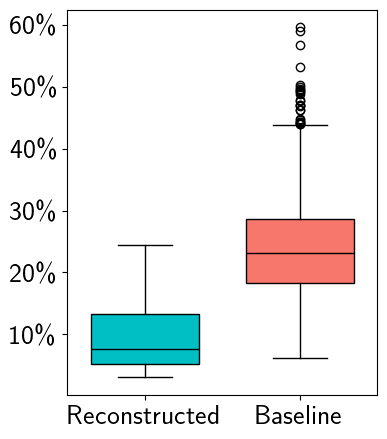

In [18]:
plt.figure(figsize=(4, 5))
bp = plt.boxplot([seg_scores, null_mismatch], 
                widths = 0.7,
                medianprops=dict(color='black'),
                patch_artist=True, labels=['Reconstructed', 'Baseline'])
colors = ['#00bfc4', '#f8776c']

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
plt.yticks([0.1, 0.2, 0.3, 0.4, 0.5, 0.6], ['10\%', '20\%', '30\%', '40\%', '50\%', '60\%'], fontsize=20)
plt.xticks(fontsize = 20)
plt.show()

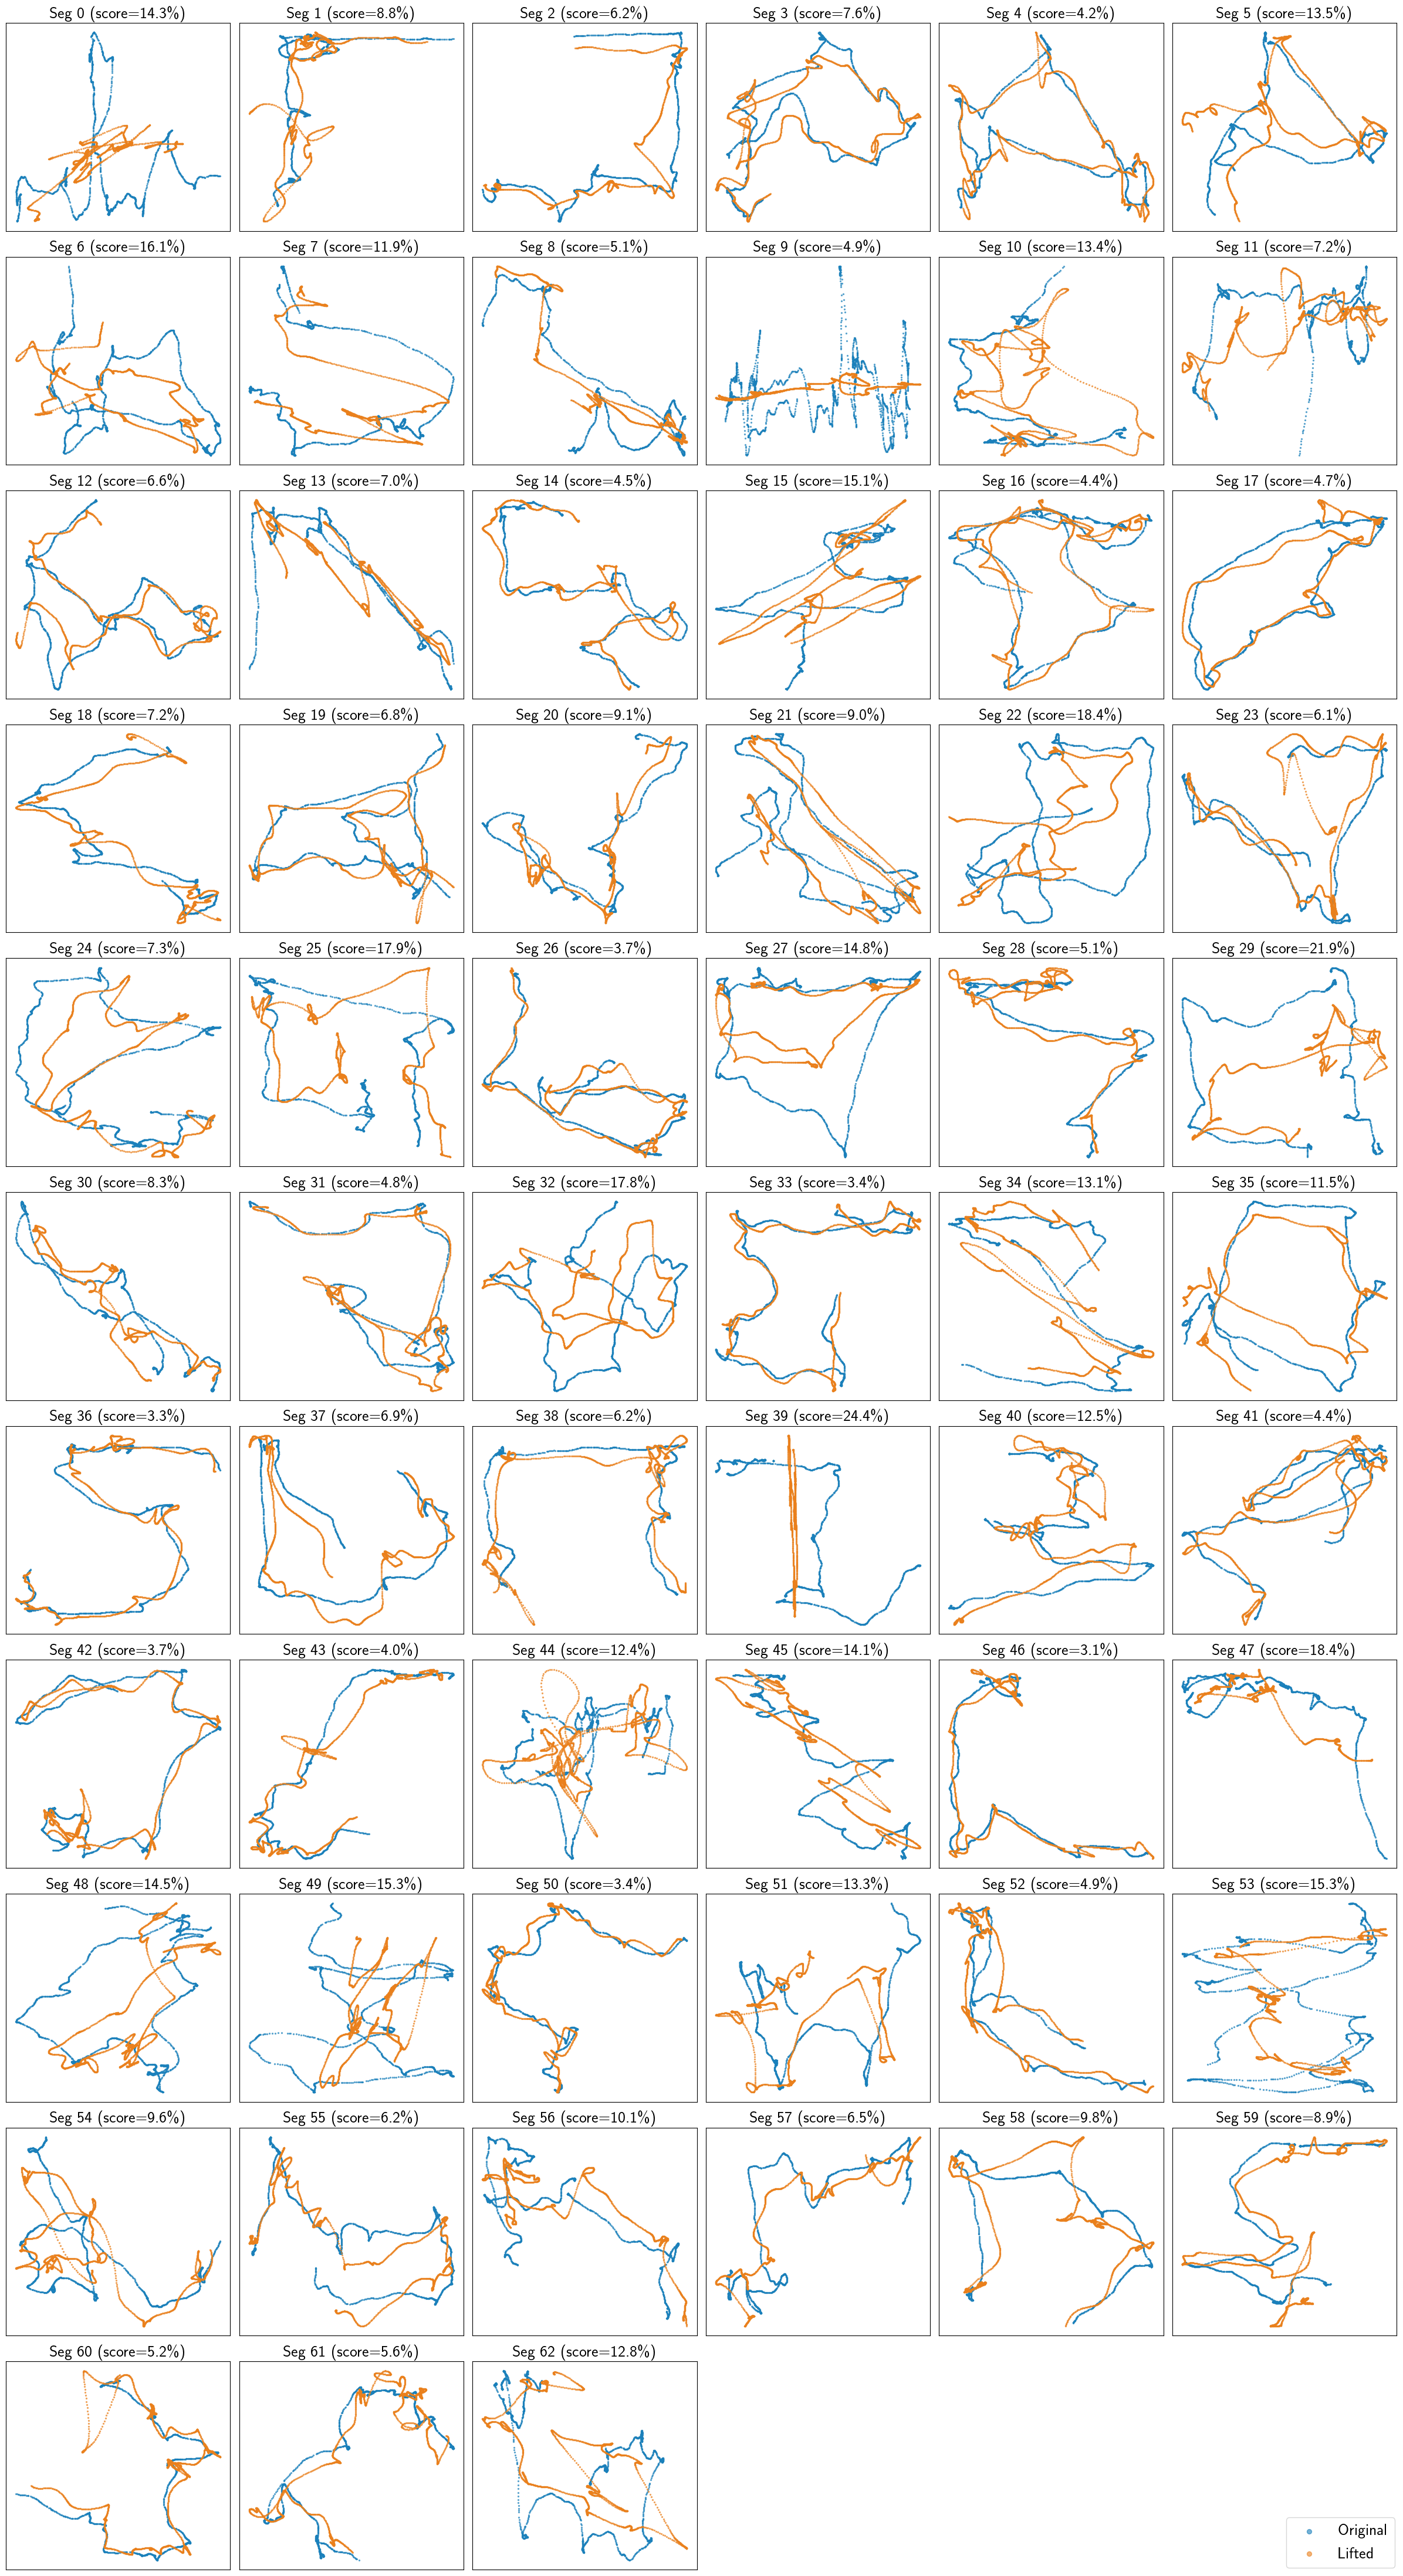

In [19]:
from affine_transform.get_transform_mat import get_transform_mat, apply_transform_mat

num_seg = len(lifted_coord_smooth) // LEN_SEG
ncols = 6
nrows = (num_seg + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 4))
axes = axes.flatten()

for i in range(num_seg):
    orig_seg = original_coord[i * LEN_SEG:(i + 1) * LEN_SEG]
    lift_seg = lifted_coord_smooth[i * LEN_SEG:(i + 1) * LEN_SEG]

    transform_mat = get_transform_mat(lift_seg, orig_seg)
    lift_seg_transformed = apply_transform_mat(lift_seg, transform_mat)

    ax = axes[i]
    ax.scatter(orig_seg[:, 0], orig_seg[:, 1], s=2, alpha=0.6, color='#1a80bb', label='Original')
    ax.scatter(lift_seg_transformed[:, 0], lift_seg_transformed[:, 1], s=2, alpha=0.6, color='#ea801c', label='Lifted')

    # Handle both normal text mode and TeX text mode for percent rendering.
    title = f"Seg {i} (score={seg_scores[i] * 100:.1f}%)"
    if plt.rcParams.get('text.usetex', False):
        title = title.replace('%', r'\%')
    ax.set_title(title, fontsize=20)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

# Hide unused axes
for j in range(num_seg, len(axes)):
    axes[j].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right', markerscale=4, fontsize=20)

#plt.suptitle('Original vs Lifted Trajectory — All Segments', fontsize=13, y=1.01)
plt.tight_layout()
#plt.savefig("../Gardner_data_test/figures/segmental_comparison_total.png", dpi=300)
plt.show()


## Error accumulation
Here, we visualize the lifted coordinate without smoothing

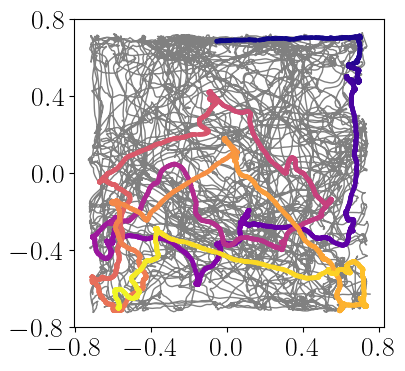

In [20]:
original = original_coord
len_seg = LEN_SEG
lifted = lifted_coord
original_seg = original[2*len_seg:(4+1)*len_seg]
colors_seg = plt.cm.plasma(np.linspace(0, 1, len(original_seg)))

plt.figure(figsize= (4,4))
plt.plot(original[:,0],original[:,1], linewidth = 1, color = "grey")
plt.scatter(original_seg[:,0],original_seg[:,1], color = colors_seg, s = 6, zorder = 2)
plt.xticks([-0.8, -0.4, 0.0, 0.4, 0.8])
plt.yticks([-0.8, -0.4, 0.0, 0.4, 0.8])
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
#plt.savefig("figures/segment_2_to_4_highlighted.pdf", transparent = True, bbox_inches = "tight")
plt.show()


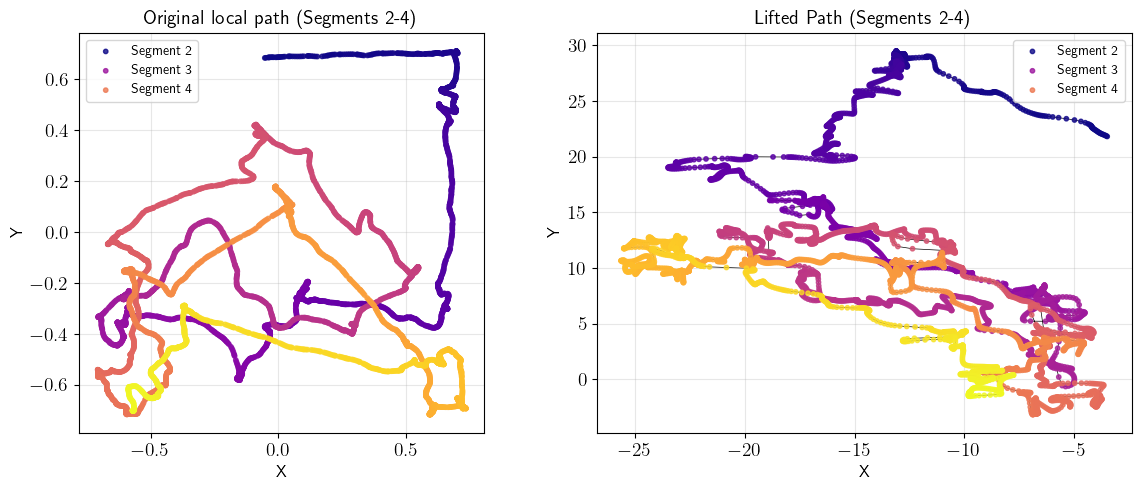

In [22]:
# Plot original and lifted paths for a specified segment range
# Specify the segment range
start_segment = 2
end_segment = 4

len_seg = 2000
start_idx = start_segment * len_seg
end_idx = (end_segment + 1) * len_seg

# Assign colors to each point based on segment membership
point_colors_idx = np.zeros(end_idx - start_idx, dtype=int)
for i in range(end_idx - start_idx):
    segment_num = (start_idx + i) // len_seg - start_segment
    point_colors_idx[i] = segment_num

# Use a shared plasma colormap over all points in the selected range
plasma_colors = plt.cm.plasma(np.linspace(0, 1, end_idx - start_idx))
num_segments = end_segment - start_segment + 1

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot original path
axes[0].plot(original[start_idx:end_idx, 0], original[start_idx:end_idx, 1], color='grey', linewidth=0.5, zorder=1)
for seg in range(num_segments):
    mask = point_colors_idx == seg
    axes[0].scatter(
        original[start_idx:end_idx, 0][mask],
        original[start_idx:end_idx, 1][mask],
        c=plasma_colors[mask],
        s=10,
        alpha=0.8,
        label=f'Segment {start_segment + seg}',
        zorder=2,
    )
axes[0].set_ylabel('Y', fontsize=12)
axes[0].set_xlabel('X', fontsize=12)
axes[0].set_title(f'Original local path (Segments {start_segment}-{end_segment})', fontsize=14)
axes[0].tick_params(axis='both', labelsize=14)
axes[0].set_aspect('equal')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=10)

# Plot lifted path
axes[1].plot(lifted[start_idx:end_idx, 0], lifted[start_idx:end_idx, 1], color='black', linewidth=0.5, zorder=1)
for seg in range(num_segments):
    mask = point_colors_idx == seg
    axes[1].scatter(
        lifted[start_idx:end_idx, 0][mask],
        lifted[start_idx:end_idx, 1][mask],
        c=plasma_colors[mask],
        s=10,
        alpha=0.8,
        label=f'Segment {start_segment + seg}',
        zorder=2,
    )
axes[1].set_ylabel('Y', fontsize=12)
axes[1].set_xlabel('X', fontsize=12)
axes[1].set_title(f'Lifted Path (Segments {start_segment}-{end_segment})', fontsize=14)
axes[1].tick_params(axis='both', labelsize=14)
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=10)

plt.tight_layout()
#plt.savefig(f'Gardner_data_test/figures/original_vs_lifted_segments_{start_segment}_{end_segment}.pdf', bbox_inches='tight', transparent=True)
plt.show()


/tmp/ipykernel_1002271/575697833.py:60: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(fontsize=10)


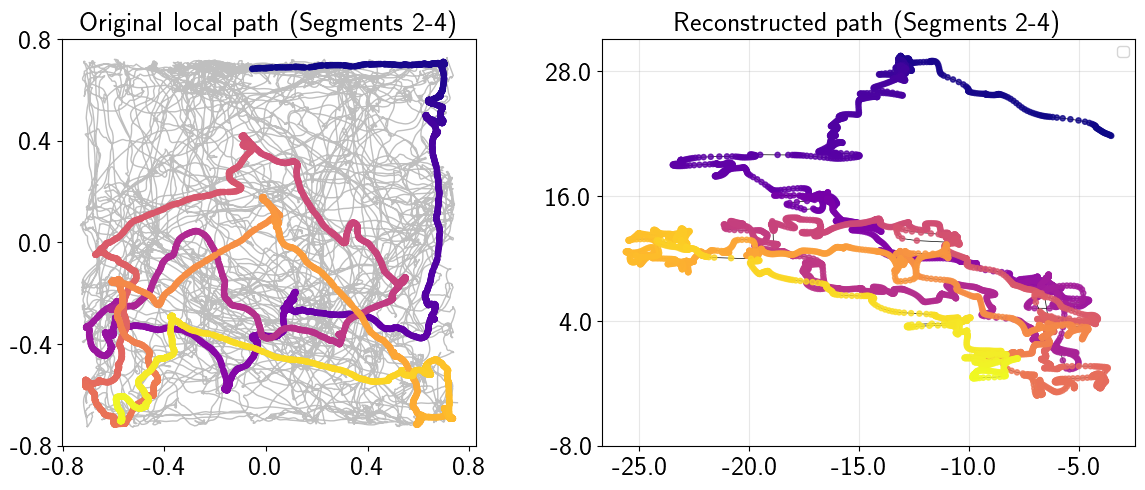

In [26]:
# Plot original and lifted paths for a specified segment range
# Specify the segment range
start_segment = 2
end_segment = 4

len_seg = 2000
start_idx = start_segment * len_seg
end_idx = (end_segment + 1) * len_seg

# Assign colors to each point based on segment membership
point_colors_idx = np.zeros(end_idx - start_idx, dtype=int)
for i in range(end_idx - start_idx):
    segment_num = (start_idx + i) // len_seg - start_segment
    point_colors_idx[i] = segment_num

# Use plasma colors over the selected range
original_seg = original[start_idx:end_idx]
plasma_colors = plt.cm.plasma(np.linspace(0, 1, end_idx - start_idx))
num_segments = end_segment - start_segment + 1

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left plot: match cell 60 style
axes[0].plot(original[:, 0], original[:, 1], linewidth=1, color='grey', alpha = 0.5)
axes[0].scatter(original_seg[:, 0], original_seg[:, 1], color=plasma_colors, s=14, zorder=2)
#axes[0].set_ylabel('Y', fontsize=12)
#axes[0].set_xlabel('X', fontsize=12)
axes[0].set_title(f'Original local path (Segments {start_segment}-{end_segment})', fontsize=20, x=0.5, loc='center')
axes[0].set_xticks([-0.8, -0.4, 0.0, 0.4, 0.8])
axes[0].set_yticks([-0.8, -0.4, 0.0, 0.4, 0.8])
axes[0].set_aspect('equal')

# Plot lifted path
axes[1].plot(lifted[start_idx:end_idx, 0], lifted[start_idx:end_idx, 1], color='black', linewidth=0.5, zorder=1)
for seg in range(num_segments):
    mask = point_colors_idx == seg
    axes[1].scatter(
        lifted[start_idx:end_idx, 0][mask],
        lifted[start_idx:end_idx, 1][mask],
        c=plasma_colors[mask],
        s=14,
        alpha=0.8,
        #label=f'Segment {start_segment + seg}',
        zorder=2,
    )
#axes[1].set_ylabel('Y', fontsize=12)
#axes[1].set_xlabel('X', fontsize=12)
axes[1].set_title(f'Reconstructed path (Segments {start_segment}-{end_segment})', fontsize=20, x=0.5, loc='center')

# Set requested y-ticks on the right
axes[1].set_yticks([-8, 4, 16, 28])

# Match x/y tick font and style across both plots
for ax in axes:
    ax.tick_params(axis='both', labelsize=20)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=10)

plt.tight_layout()
#plt.savefig(f'figures/original_vs_lifted_segments_{start_segment}_{end_segment}.pdf', bbox_inches='tight', transparent=True)
plt.show()